# MMIA 6013 · Taller 01

# Parte 0 — El modelo base y la distribución

**Modelo:** GPT-2 (124M parámetros)

**Objetivo:** Analizar la distribución del siguiente token, comprobar las tres palancas de decodificación y evidenciar el límite de un modelo base.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

from src.config import GPT2_MODEL, SEED

torch.manual_seed(SEED)
np.random.seed(SEED)

plt.style.use("ggplot")

## Carga del modelo base

In [3]:
tokenizer = AutoTokenizer.from_pretrained(GPT2_MODEL)
model = AutoModelForCausalLM.from_pretrained(GPT2_MODEL)

model.eval()

print(f"Modelo: {GPT2_MODEL}")
print(f"Vocabulario: {tokenizer.vocab_size} tokens")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Modelo: openai-community/gpt2
Vocabulario: 50257 tokens


# Funciones — Parte 0.a

Estas funciones implementan el análisis de la distribución del siguiente token:

- Obtener logits
- Aplicar temperatura
- Calcular entropía
- Medir el núcleo al 90 %
- Graficar la distribución

In [4]:
def get_next_logits(model, tokenizer, text: str):
    """
    Obtiene los logits del siguiente token.
    """
    inputs = tokenizer(text, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.logits[0, -1]


def softmax_temperature(logits, temperature=1.0):
    """
    Convierte logits en probabilidades aplicando temperatura.
    """
    scaled = logits / temperature
    return torch.softmax(scaled, dim=-1)


def top_tokens(probabilities, tokenizer, top_n=15):
    """
    Devuelve los N tokens más probables.
    """
    values, ids = torch.topk(probabilities, top_n)

    tokens = [repr(tokenizer.decode(i.item())) for i in ids]

    return pd.DataFrame({
        "token": tokens,
        "probability": values.numpy()
    })


def entropy_bits(probabilities):
    """
    Entropía de Shannon en bits.
    """
    p = probabilities.numpy()
    p = p[p > 0]

    return float(-(p * np.log2(p)).sum())


def nucleus_size(probabilities, threshold=0.90):
    """
    Número mínimo de tokens necesarios para acumular
    el 90% de la masa de probabilidad.
    """
    sorted_probs, _ = torch.sort(probabilities, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=0)

    return int((cumulative < threshold).sum()) + 1


def plot_distribution(probabilities, tokenizer, temperature, top_n=15):

    df = top_tokens(probabilities, tokenizer, top_n)

    plt.figure(figsize=(10,4))

    plt.bar(df["token"], df["probability"])

    plt.title(f"Top {top_n} tokens | Temperature = {temperature}")
    plt.xlabel("Token")
    plt.ylabel("Probability")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


def run_distribution_analysis(model, tokenizer, prefix, temperatures):

    logits = get_next_logits(model, tokenizer, prefix)

    metrics = []

    for T in temperatures:

        probs = softmax_temperature(logits, T)

        plot_distribution(probs, tokenizer, T)

        metrics.append({
            "temperature": T,
            "entropy_bits": round(entropy_bits(probs), 3),
            "nucleus_90": nucleus_size(probs)
        })

    return pd.DataFrame(metrics)

# Funciones — Parte 0.b

Comprobación de las tres palancas de decodificación:

1. `do_sample=False` ignora la temperatura.
2. `top_k=1` reproduce greedy.
3. Comparación visual entre `top_k` y `top_p`.
4. Degeneración mediante generación greedy.

In [5]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=60,
    do_sample=False,
    temperature=1.0,
    top_k=50,
    top_p=1.0
):
    """
    Generación genérica de texto.
    """
    inputs = tokenizer(prompt, return_tensors="pt")

    kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        pad_token_id=tokenizer.eos_token_id
    )

    if do_sample:
        kwargs["temperature"] = temperature
        kwargs["top_k"] = top_k
        kwargs["top_p"] = top_p

    output = model.generate(**inputs, **kwargs)

    return tokenizer.decode(output[0], skip_special_tokens=True)


def compare_temperature_without_sampling(model, tokenizer, prefix):

    print("=== Temperature 0.2 ===")
    print(generate_text(
        model,
        tokenizer,
        prefix,
        do_sample=False,
        temperature=0.2
    ))

    print("\n=== Temperature 1.5 ===")
    print(generate_text(
        model,
        tokenizer,
        prefix,
        do_sample=False,
        temperature=1.5
    ))


def compare_topk_equals_greedy(model, tokenizer, prefix, runs=5):

    greedy = generate_text(
        model,
        tokenizer,
        prefix,
        do_sample=False
    )

    sampled = [
        generate_text(
            model,
            tokenizer,
            prefix,
            do_sample=True,
            top_k=1
        )
        for _ in range(runs)
    ]

    return greedy, sampled


def plot_topk_topp_cutoff(model, tokenizer, prefix):

    logits = get_next_logits(model, tokenizer, prefix)
    probs = softmax_temperature(logits)

    sorted_probs, ids = torch.sort(probs, descending=True)

    cumulative = torch.cumsum(sorted_probs, dim=0)

    tokens = [
        repr(tokenizer.decode(i.item()))
        for i in ids[:15]
    ]

    colors = []

    for i in range(15):
        if i < 5:
            colors.append("steelblue")
        elif cumulative[i] <= 0.9:
            colors.append("orange")
        else:
            colors.append("lightgray")

    plt.figure(figsize=(10,4))

    plt.bar(tokens, sorted_probs[:15], color=colors)

    plt.title("Azul = top_k (5) | Naranja = núcleo top_p 0.9")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


def generate_degenerate_text(model, tokenizer, prefix):

    return generate_text(
        model,
        tokenizer,
        prefix,
        max_new_tokens=100,
        do_sample=False
    )

# Funciones — Parte 0.c

In [6]:
def run_instruction_prompt(model, tokenizer, prompt):

    response = generate_text(
        model,
        tokenizer,
        prompt,
        max_new_tokens=120,
        do_sample=False
    )

    return response

In [7]:
TEMPERATURES = [0.1, 0.7, 1.0, 1.5, 2.0]

PREFIX_CONFIDENT = "Once upon a"

PREFIX_UNCERTAIN = "The meeting concluded that"

INSTRUCTION_PROMPT = """
Classify the following support ticket into one category:

Finance
Technical
HR

Ticket:
The employee cannot access payroll.
"""

# Ejecución — Parte 0.a

Se analizan dos prefijos:

- **Seguro:** contexto donde el modelo concentra la probabilidad.
- **Incierto:** contexto donde la distribución es más dispersa.

Para cada temperatura se reportan:

- Gráfica de los 15 tokens más probables
- Entropía (bits)
- Tamaño del núcleo al 90 %

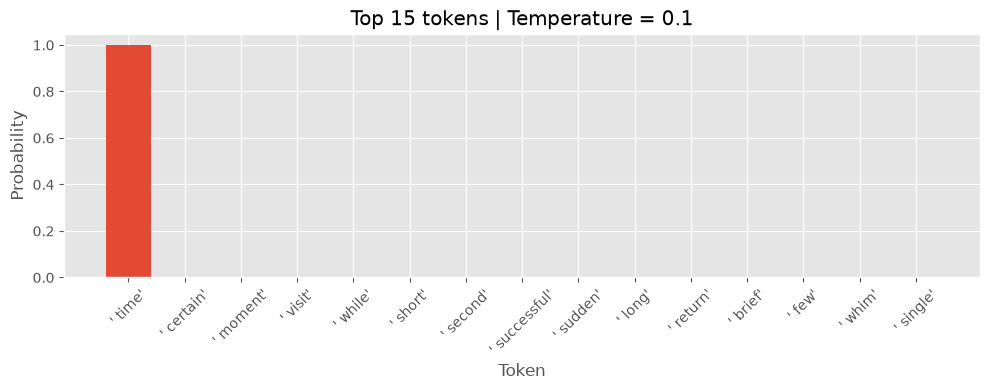

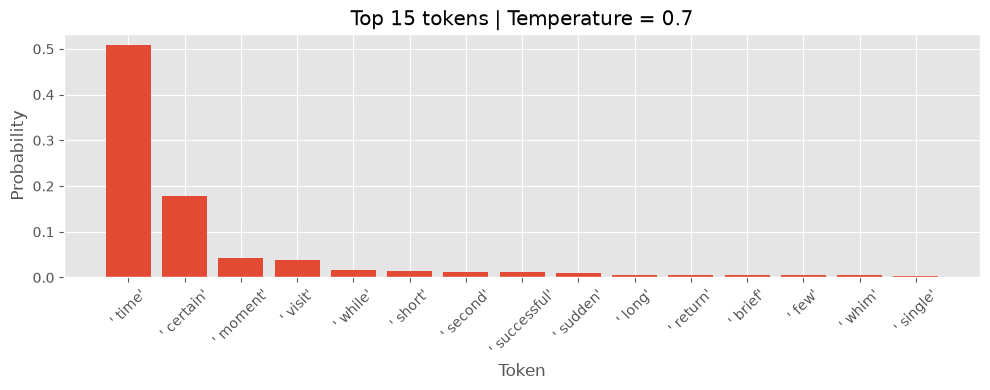

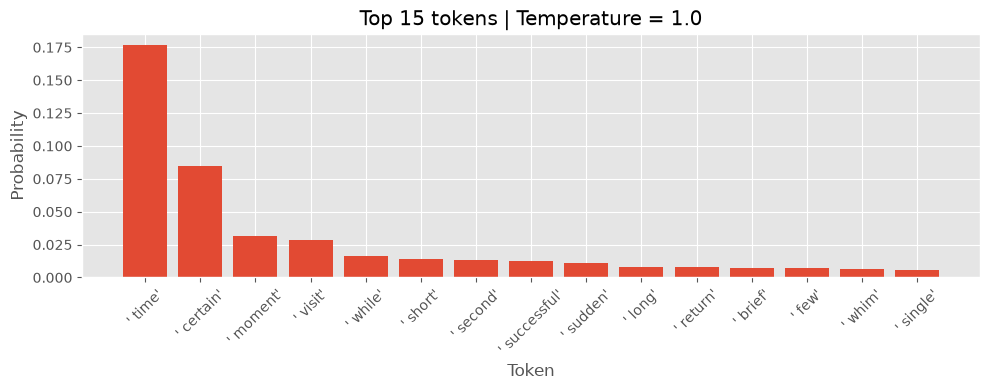

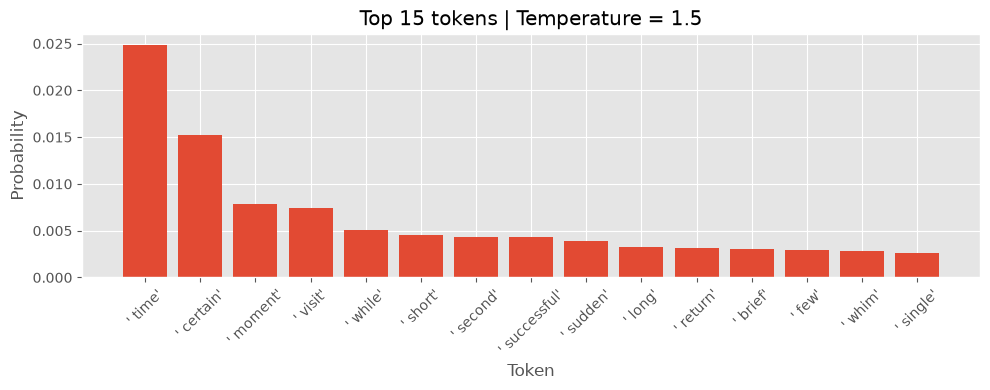

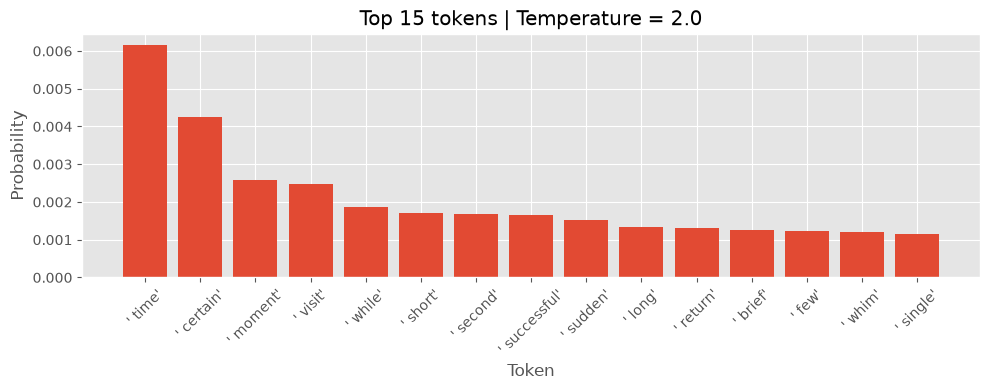

,temperature,entropy_bits,nucleus_90
0,0.1,0.008,1
1,0.7,3.568,33
2,1.0,8.507,1956
3,1.5,12.623,11187
4,2.0,13.937,19623


In [8]:
metrics_confident = run_distribution_analysis(
    model,
    tokenizer,
    PREFIX_CONFIDENT,
    TEMPERATURES
)

metrics_confident

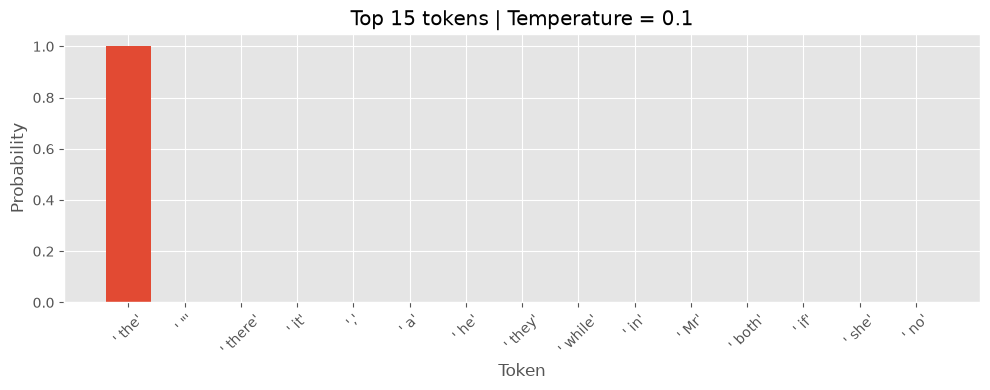

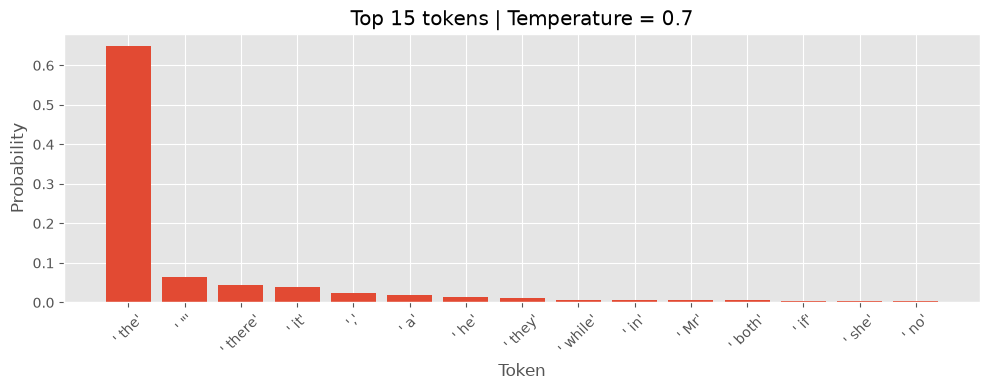

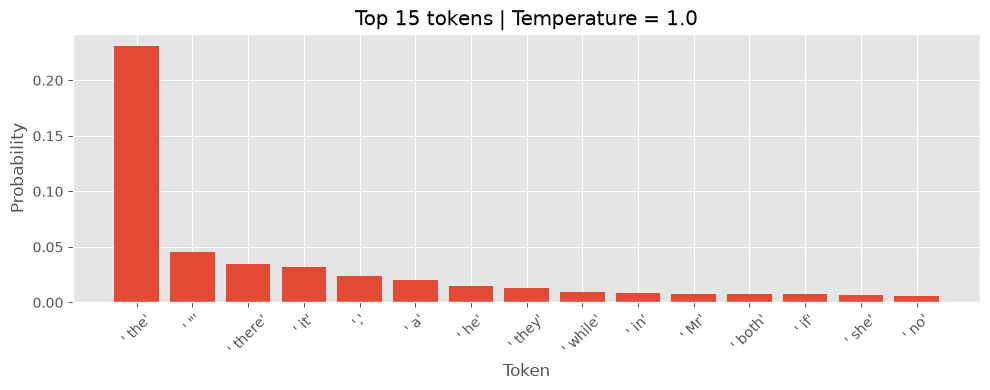

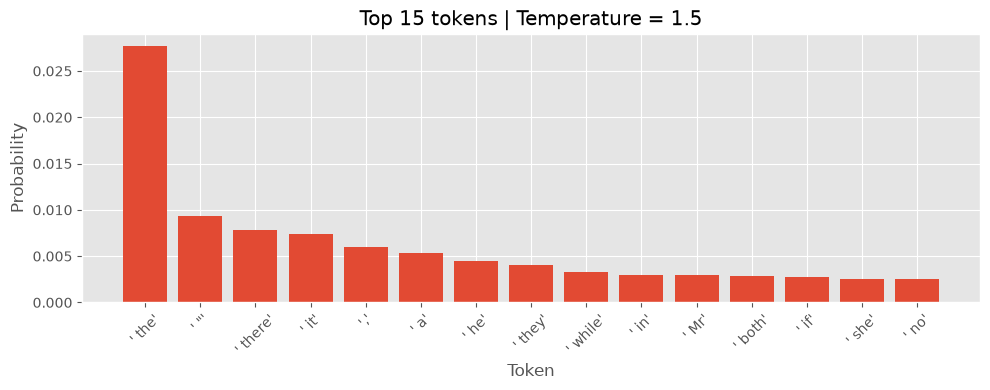

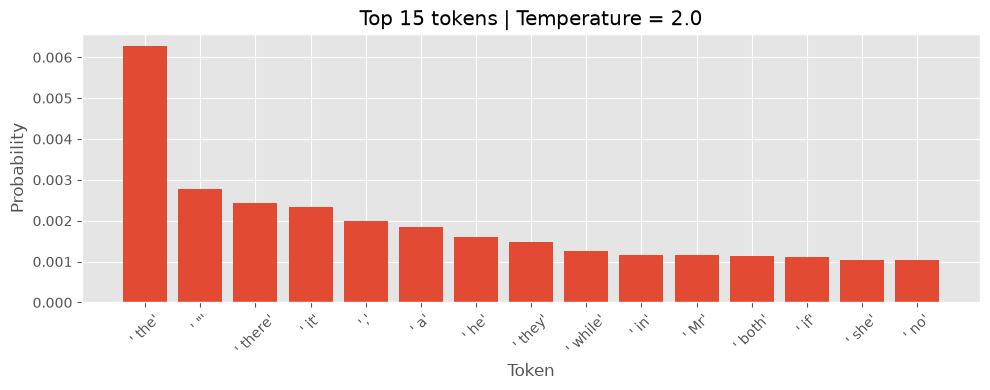

,temperature,entropy_bits,nucleus_90
0,0.1,0.000,1
1,0.7,2.940,17
2,1.0,8.393,3188
3,1.5,13.063,14834
4,2.0,14.212,21191


In [9]:
metrics_uncertain = run_distribution_analysis(
    model,
    tokenizer,
    PREFIX_UNCERTAIN,
    TEMPERATURES
)

metrics_uncertain

# Ejecución — Parte 0.b

Comprobación experimental de las tres palancas de decodificación.

In [10]:
compare_temperature_without_sampling(
    model,
    tokenizer,
    PREFIX_CONFIDENT
)

=== Temperature 0.2 ===
Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger

=== Temperature 1.5 ===
Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger


In [11]:
greedy, sampled = compare_topk_equals_greedy(
    model,
    tokenizer,
    PREFIX_CONFIDENT
)

print("GREEDY\n")
print(greedy)

print("\nTOP_K = 1\n")

for i, text in enumerate(sampled, 1):
    print(f"Corrida {i}")
    print(text)
    print("-"*50)

GREEDY

Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger

TOP_K = 1

Corrida 1
Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger
--------------------------------------------------
Corrida 2
Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger
--------------------------------------------------
Corrida 3
Once upon a time, th

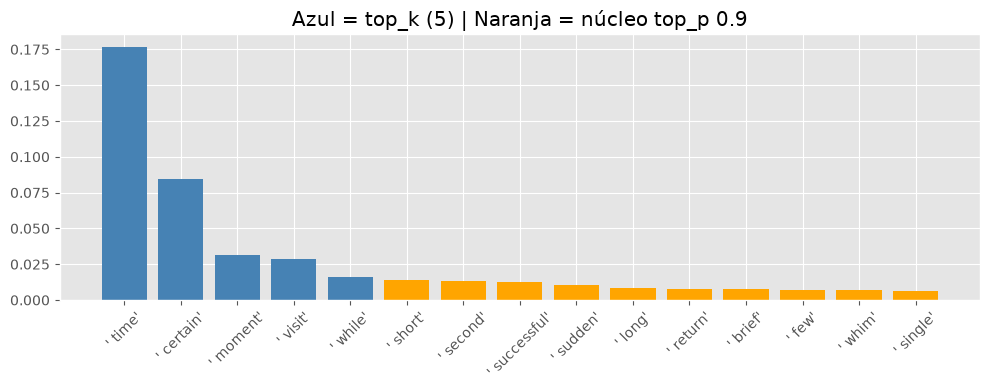

In [12]:
plot_topk_topp_cutoff(
    model,
    tokenizer,
    PREFIX_CONFIDENT
)

In [13]:
degenerate = generate_degenerate_text(
    model,
    tokenizer,
    PREFIX_CONFIDENT
)

print(degenerate)

Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and


# Ejecución — Parte 0.c

El mismo prompt que utilizaremos posteriormente se entrega a GPT-2 para demostrar que un modelo base **no sigue instrucciones**.

In [14]:
response = run_instruction_prompt(
    model,
    tokenizer,
    INSTRUCTION_PROMPT
)

print(response)


Classify the following support ticket into one category:

Finance
Technical
HR

Ticket:
The employee cannot access payroll.

The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll. The employee cannot access payroll
